<a href="https://colab.research.google.com/github/Rizkyard17/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Studi Kasus

Sebuah perusahaan telekomunikasi ingin mengurangi jumlah pelanggan yang berhenti berlangganan (churn).

Masalah bisnis:

**Jika perusahaan dapat mengetahui pelanggan yang berpotensi churn lebih awal, mereka dapat memberikan promo atau layanan khusus untuk mempertahankan pelanggan tersebut.**

# Business Question

Pertanyaan yang ingin dijawab:

1.   Apakah pelanggan baru lebih sering churn?
2.   Apakah biaya bulanan tinggi meningkatkan churn?
3.   Jenis kontrak mana yang paling berisiko?
4.   Apakah pelanggan tanpa layanan tambahan lebih mudah churn?

# Import Library

In [24]:
# Data collection
import kagglehub
import os
import pandas as pd

#EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collection

In [16]:
# path data
path = kagglehub.dataset_download("abdallahwagih/telco-customer-churn")

# list path
for file in os.listdir(path):
    print(file)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Telco_customer_churn.xlsx


In [17]:
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Drop Kolom

In [19]:
# drop kolom yang tidak digunakan
drop_kolom = ["CustomerID", "Count", "Churn Label", "Churn Score", "Churn Reason"]
df.drop(drop_kolom, axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            7043 non-null   object 
 1   State              7043 non-null   object 
 2   City               7043 non-null   object 
 3   Zip Code           7043 non-null   int64  
 4   Lat Long           7043 non-null   object 
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   object 
 8   Senior Citizen     7043 non-null   object 
 9   Partner            7043 non-null   object 
 10  Dependents         7043 non-null   object 
 11  Tenure Months      7043 non-null   int64  
 12  Phone Service      7043 non-null   object 
 13  Multiple Lines     7043 non-null   object 
 14  Internet Service   7043 non-null   object 
 15  Online Security    7043 non-null   object 
 16  Online Backup      7043 

## Sesuaikan tipe data

In [20]:
# ubah ke numerik
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

## Missing Value

In [21]:
missing = (df.isnull().sum().sort_values(ascending=False))

missing[missing > 0]

,0
Total Charges,11


## Target Analysis

In [22]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [23]:
df['Churn Value'].value_counts(normalize=True)

,proportion
Churn Value,
0,0.73463
1,0.26537


# Exploratory Data Analysis (EDA)

## Churn Rate

<Axes: xlabel='Churn Value', ylabel='count'>

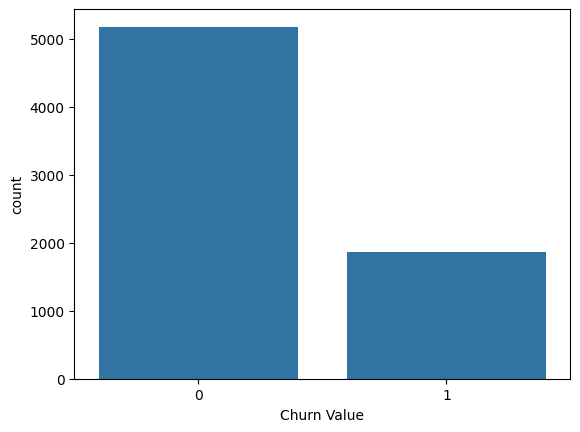

In [25]:
sns.countplot(x='Churn Value',data=df)

<Axes: xlabel='Tenure Months', ylabel='Count'>

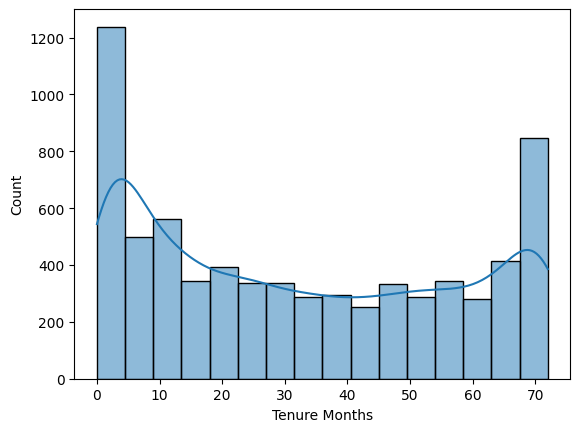

In [26]:
sns.histplot(df['Tenure Months'],kde=True)

<Axes: xlabel='Monthly Charges', ylabel='Count'>

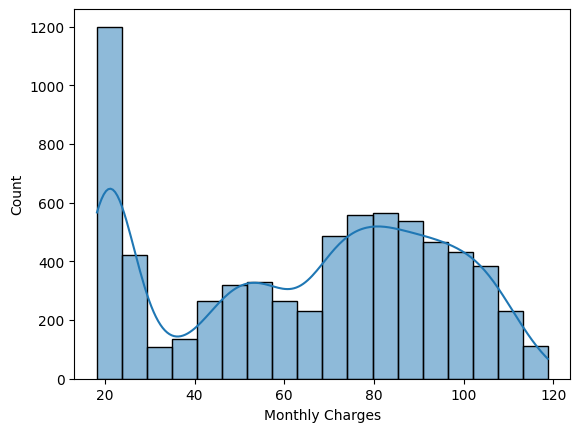

In [27]:
sns.histplot(df['Monthly Charges'],kde=True)

<Axes: xlabel='Contract', ylabel='count'>

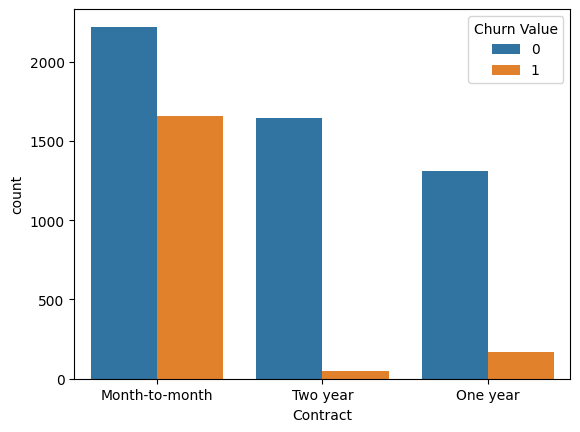

In [29]:
sns.countplot(x='Contract', hue='Churn Value',data=df)

<Axes: xlabel='Internet Service', ylabel='count'>

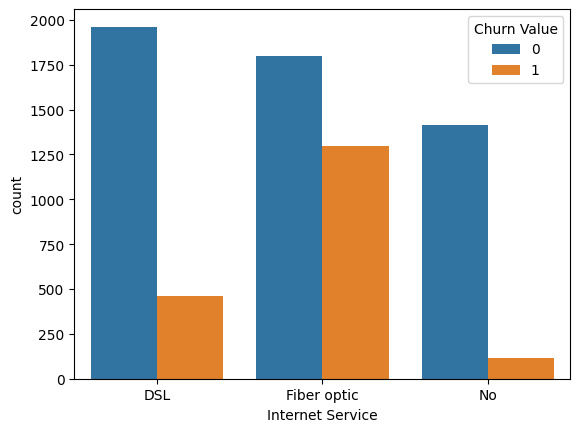

In [30]:
sns.countplot(x='Internet Service',hue='Churn Value',data=df)